# Recommender embeddings, from scratch

**Session 07 — Creating Useful Representations**

A matrix-factorization recommender is just two embedding tables — one for users, one for movies — trained so that

$$\text{rating}(u, m) \;\approx\; \mathbf{u}_u \cdot \mathbf{m}_m + \bar y$$

We use **2-dimensional** embeddings on purpose so we can plot them directly, and we **snapshot them during training** to watch random noise turn into structure: same-genre movies cluster, each pure-taste user lands among the movies they like, and **blended-taste users land between the genres they enjoy**.

The whole model is ~8 lines. The whole training loop is ~5 lines. That is the teaching moment.

**Run:**
```bash
pip install torch numpy matplotlib
```

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
torch.manual_seed(0)
rng = np.random.default_rng(0)

## 1. A synthetic world

5 genres, 10 movies per genre = **50 movies**. Users come in two flavours:

- **Pure-taste** users (50 of them): each loves exactly one genre.
- **Blended-taste** users (12 of them): each loves *two* genres equally — for example a `Romance+Comedy` fan who likes both rom-coms and pure comedies.

Ratings are generated with a simple rule: **4.5 ± noise** if the movie's genre matches one of the user's preferred genres, **1.5 ± noise** otherwise. No structure is fed to the model directly — only `(user_id, movie_id, rating)` triples.

In [2]:
GENRES = ["Action", "Romance", "Sci-Fi", "Comedy", "Horror"]
GENRE_COLORS = ["#e63946", "#e9a23b", "#2a9d8f", "#457b9d", "#7d3c98"]

MOVIES_BY_GENRE = {
    "Action":  ["Mad Max", "Die Hard", "John Wick", "Top Gun", "Rambo",
                "Speed", "Heat", "Kill Bill", "The Raid", "Mission Impossible"],
    "Romance": ["Notting Hill", "Titanic", "La La Land", "The Notebook",
                "Pride and Prejudice", "Casablanca", "Roman Holiday",
                "Before Sunrise", "Amelie", "Brooklyn"],
    "Sci-Fi":  ["Interstellar", "Blade Runner", "The Matrix", "Arrival",
                "Inception", "Dune", "2001", "Alien", "Ex Machina", "Gattaca"],
    "Comedy":  ["Anchorman", "Superbad", "Bridesmaids", "The Hangover",
                "Airplane", "Groundhog Day", "Some Like It Hot",
                "Step Brothers", "Booksmart", "Borat"],
    "Horror":  ["The Shining", "Hereditary", "Get Out", "The Exorcist",
                "Halloween", "A Quiet Place", "It Follows", "Midsommar",
                "The Witch", "Sinister"],
}
# crea 2 array, uno con i titoli dei film e l'altro con id del genere di quei film
movie_title, movie_genre = [], []
for g_id, g_name in enumerate(GENRES):
    for title in MOVIES_BY_GENRE[g_name]:
        movie_title.append(title)
        movie_genre.append(g_id)
movie_genre = np.array(movie_genre)

N_M = len(movie_title)

# 10 pure fans per genre = 50 users; each user_taste is a *set* of liked genres
user_taste = []
for g in range(5):
    user_taste.extend([{g}] * 10) # [{0},{0}...]
    
# 12 blended-taste users across 3 cross-genre combinations
BLENDS = [
    ({0, 2}, "Action+Sci-Fi"),     # superhero / blockbuster fans
    ({1, 3}, "Romance+Comedy"),    # rom-com fans
    ({2, 4}, "Sci-Fi+Horror"),     # cosmic-horror fans
]
blend_label_per_user = [None] * len(user_taste)
for blend_set, label in BLENDS:
    for _ in range(4):
        user_taste.append(blend_set)
        blend_label_per_user.append(label)
# print(blend_label_per_user)
N_U = len(user_taste)
print(f"{N_U=} {N_M=}")
# Build ratings: rating ~ 4.5 if any of user's preferred genres == movie genre, else ~ 1.5
rows = []
for u in range(N_U):
    for m in range(N_M):
        match = movie_genre[m] in user_taste[u]
        r = (4.5 if match else 1.5) + rng.normal(0, 0.4)
        rows.append((u, m, np.clip(r, 1.0, 5.0)))
ratings = np.array(rows, dtype=np.float32)

u_idx = torch.tensor(ratings[:, 0], dtype=torch.long)
m_idx = torch.tensor(ratings[:, 1], dtype=torch.long)
y     = torch.tensor(ratings[:, 2], dtype=torch.float32)
y_mean = y.mean()

print(f"World: {N_U} users  \u00d7  {N_M} movies ( \u00d7  {len(GENRES)} genres ) "
      f"\u2192 {len(ratings):,} ratings")

N_U=62 N_M=50
World: 62 users  ×  50 movies ( ×  5 genres ) → 3,100 ratings


## 2. The whole model

Two embedding tables, a dot product, and a global bias. That's it. `nn.Embedding(N, d)` is just a learnable lookup table of shape `(N, d)`.

In [3]:
DIM = 2  # 2D so we can plot directly

class MF(nn.Module):
    def __init__(self, n_users, n_movies, dim):
        super().__init__()
        self.U = nn.Embedding(n_users, dim)
        self.M = nn.Embedding(n_movies, dim)
        nn.init.normal_(self.U.weight, std=0.1)
        nn.init.normal_(self.M.weight, std=0.1)
        
    def forward(self, u, m):
        return (self.U(u) * self.M(m)).sum(-1) + y_mean   # dot product + global bias

model = MF(N_U, N_M, DIM)
opt = torch.optim.Adam(model.parameters(), lr=0.05)

## 3. Training, with snapshots

We train for 500 epochs and save the embedding tables at epochs **0, 5, 25, 100, 500**, so we can plot the geometry as it forms.

In [4]:
SNAPSHOTS = [0, 5, 25, 100, 500]
N_EPOCHS = SNAPSHOTS[-1] + 1

snaps = {}
losses = []
for epoch in range(N_EPOCHS):
    if epoch in SNAPSHOTS:
        snaps[epoch] = (
            model.U.weight.detach().numpy().copy(),
            model.M.weight.detach().numpy().copy(),
        )
        
    pred = model(u_idx, m_idx)
    '''
    pred = tensor([
        (vettore_utente_0  · vettore_film_0)  + y_mean,  # pred[0]
        (vettore_utente_0  · vettore_film_1)  + y_mean,  # pred[1]
        (vettore_utente_0  · vettore_film_2)  + y_mean,  # pred[2]
        ...
        (vettore_utente_61 · vettore_film_50) + y_mean   # pred[3161]
    ])
    '''
    loss = ((pred - y) ** 2).mean() # MSE media
    opt.zero_grad() # svuota i gradienti
    loss.backward() # calcola il gradiente, ovvero scopre in quale direzione e di quanto muovere ogni singolo vettore per fare meno errore al giro successi
    opt.step()
    losses.append(loss.item())
print(f"final MSE = {losses[-1]:.3f}   (rating range 1-5)")

final MSE = 0.769   (rating range 1-5)


## 4. Watch the embeddings move

Squares = movies, triangles = pure-taste users, stars = blended-taste users (their colour is the average of their two genre colours).

**What to look for:**

- Epoch 0: random noise around the origin.
- Epoch 5: things start to drift outward.
- Epoch 25: five genre clusters appear, arranged in a rough pentagon around the origin.
- Epoch 100 / 500: clean separation. Each pure-taste user sits with the movies they like. **Each blended-taste star lands between the two clusters it likes** — the embedding has captured a *relationship* between genres, not just a hard cluster label.

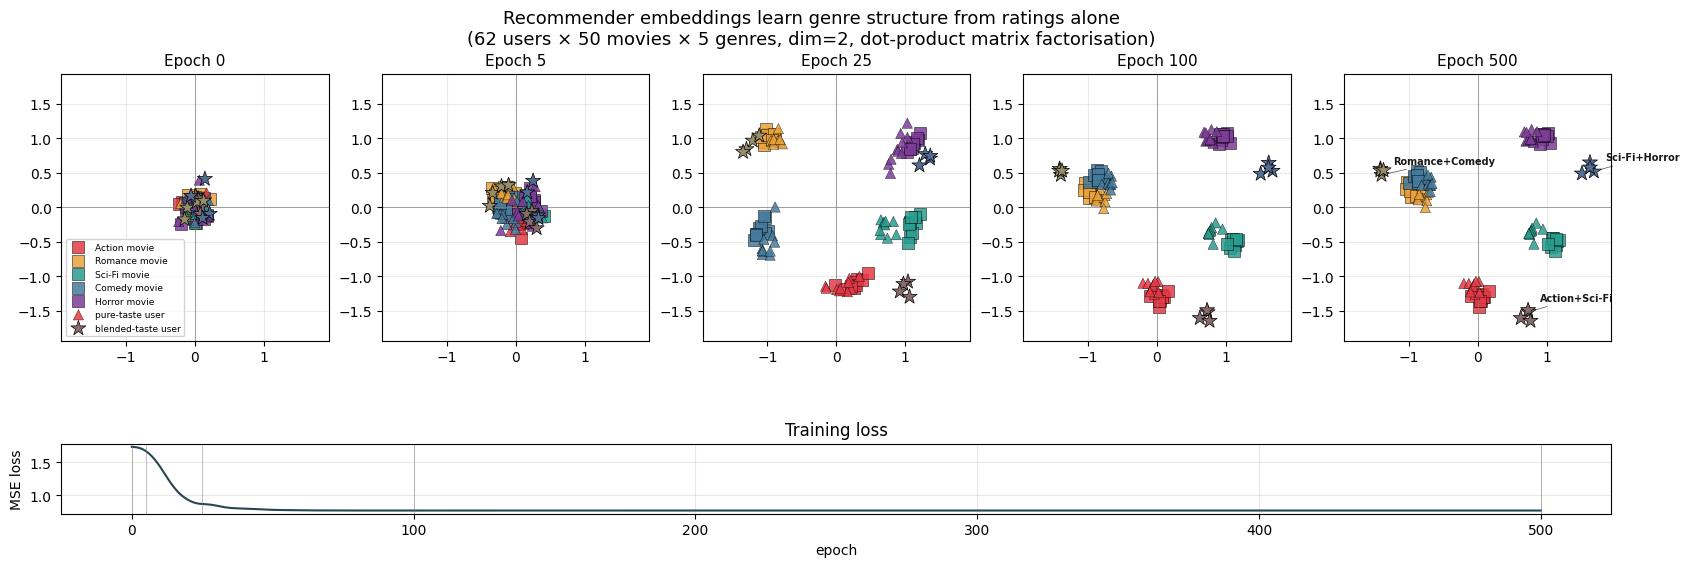

In [5]:
# Per-user colour: pure fan -> genre colour; blended -> mean of the two genre colours.
def user_color(taste_set):
    rgbs = np.array([to_rgb(GENRE_COLORS[g]) for g in taste_set])
    return rgbs.mean(axis=0)

user_colors = np.array([user_color(t) for t in user_taste])
is_blend = np.array([len(t) > 1 for t in user_taste])

fig = plt.figure(figsize=(4 * len(SNAPSHOTS), 5.8))
gs = fig.add_gridspec(2, len(SNAPSHOTS), height_ratios=[4, 1], hspace=0.55)

# shared axis limits across snapshots so the "growing into shape" effect is visible
all_pts = np.vstack([np.vstack([U, M]) for (U, M) in snaps.values()])
lim = max(abs(all_pts.min()), abs(all_pts.max())) * 1.15

for col, ep in enumerate(SNAPSHOTS):
    ax = fig.add_subplot(gs[0, col])
    U, M = snaps[ep]

    # movies as squares, coloured by genre
    for g in range(len(GENRES)):
        mask = movie_genre == g
        ax.scatter(M[mask, 0], M[mask, 1],
                   c=GENRE_COLORS[g], s=70, marker='s',
                   edgecolor='black', linewidth=0.4, alpha=0.85,
                   label=f'{GENRES[g]} movie' if col == 0 else None,
                   zorder=2)

    # pure-taste users as triangles; blended users as stars
    pure = ~is_blend
    ax.scatter(U[pure, 0], U[pure, 1],
               c=user_colors[pure], s=55, marker='^',
               edgecolor='black', linewidth=0.3, alpha=0.85,
               label='pure-taste user' if col == 0 else None, zorder=3)
    ax.scatter(U[is_blend, 0], U[is_blend, 1],
               c=user_colors[is_blend], s=130, marker='*',
               edgecolor='black', linewidth=0.5,
               label='blended-taste user' if col == 0 else None, zorder=4)

    # On the final panel, annotate one example blended user per blend type.
    if col == len(SNAPSHOTS) - 1:
        seen = set()
        for u in range(N_U):
            label = blend_label_per_user[u]
            if label is not None and label not in seen:
                seen.add(label)
                ax.annotate(label, (U[u, 0], U[u, 1]),
                            fontsize=7, alpha=0.9, fontweight='bold',
                            xytext=(8, 8), textcoords='offset points',
                            arrowprops=dict(arrowstyle='-', color='black',
                                            lw=0.5, alpha=0.7))

    ax.set_title(f'Epoch {ep}', fontsize=11)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.grid(alpha=0.25)
    ax.axhline(0, c='gray', lw=0.5)
    ax.axvline(0, c='gray', lw=0.5)
    if col == 0:
        ax.legend(fontsize=6.5, loc='lower left', framealpha=0.85)

ax_loss = fig.add_subplot(gs[1, :])
ax_loss.plot(losses, c='#264653')
for ep in SNAPSHOTS:
    ax_loss.axvline(ep, c='gray', lw=0.6, alpha=0.6)
ax_loss.set_xlabel('epoch')
ax_loss.set_ylabel('MSE loss')
ax_loss.set_title('Training loss')
ax_loss.grid(alpha=0.3)

fig.suptitle(
    'Recommender embeddings learn genre structure from ratings alone\n'
    f'({N_U} users \u00d7 {N_M} movies \u00d7 {len(GENRES)} genres, '
    f'dim={DIM}, dot-product matrix factorisation)',
    fontsize=13,
)
plt.show()

## 5. Try it: who is most similar to whom?

Once we have embeddings, *similarity* is just a dot product (or cosine similarity) between vectors. Below we pick a movie and find its nearest neighbours in embedding space — the model should return same-genre movies even though we never told it about genres.

In [6]:
M_final = model.M.weight.detach().numpy()

def nearest(title, k=5):
    i = movie_title.index(title)
    # cosine similarity
    Mn = M_final / (np.linalg.norm(M_final, axis=1, keepdims=True) + 1e-9)
    sims = Mn @ Mn[i]
    order = np.argsort(-sims)
    print(f"Nearest movies to '{title}' ({GENRES[movie_genre[i]]}):")
    for j in order[1:k+1]:
        print(f"  {sims[j]:+.3f}  {movie_title[j]:<24} ({GENRES[movie_genre[j]]})")

nearest("The Matrix")
print()
nearest("Notting Hill")
print()
nearest("The Shining")

Nearest movies to 'The Matrix' (Sci-Fi):
  +1.000  Dune                     (Sci-Fi)
  +1.000  2001                     (Sci-Fi)
  +1.000  Ex Machina               (Sci-Fi)
  +1.000  Alien                    (Sci-Fi)
  +1.000  Interstellar             (Sci-Fi)

Nearest movies to 'Notting Hill' (Romance):
  +1.000  The Notebook             (Romance)
  +1.000  The Hangover             (Comedy)
  +1.000  Casablanca               (Romance)
  +0.999  Step Brothers            (Comedy)
  +0.998  Before Sunrise           (Romance)

Nearest movies to 'The Shining' (Horror):
  +0.998  Halloween                (Horror)
  +0.998  It Follows               (Horror)
  +0.996  Hereditary               (Horror)
  +0.996  Get Out                  (Horror)
  +0.995  Midsommar                (Horror)


## 6. How big should the embedding be? Underfitting and overfitting

We've been using `DIM = 2` throughout. That makes the embeddings plottable, but is it the *right* choice for this data?

Two ways the dimension can be wrong:

- **Too small (`DIM = 1`):** the model literally can't represent five distinct genre directions, so even after training the loss stays high. **Underfitting.**
- **Too large (`DIM = 20`):** the model has so many parameters that it memorises individual rating noise instead of learning genre structure. Train loss drops to *zero*, but predictions on **held-out** ratings get worse. **Overfitting.**

The cleanest way to see both at once: split the ratings into a train and a test half, sweep `DIM`, and watch what happens.

**The trick that makes this provable:** our synthetic ratings are generated as `signal + Gaussian(σ=0.4)`. The variance of that noise — $\sigma^2 = 0.16$ — is the **irreducible loss**: even a perfect model can't predict ratings better than that on average. So when the *training* MSE drops below 0.16, we *know* the model is fitting noise, not signal. That's overfitting, made directly visible.

  DIM   #params    train MSE     test MSE
--------------------------------------------
    1       112       1.1700       1.2568
    2       224       0.7366       0.9536
    3       336       0.4212       0.6672
    5       560       0.0862       0.2137
   10      1120       0.0240       1.0301
   20      2240       0.0000       0.7451
   50      5600       0.0000       0.7074
  100     11200       0.0000       1.3484


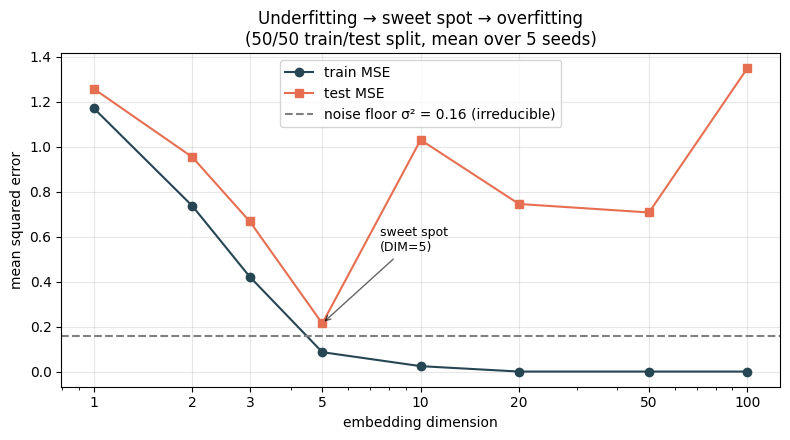

In [7]:
# =====================================================================
# 1. DIVISIONE CASUALE DEL DATASET IN DUE METÀ SPECULARI (TRAIN/TEST 50/50)
# =====================================================================

# Inizializza un generatore di numeri casuali NumPy con seed fisso (42) per garantire la riproducibilità
rng_split = np.random.default_rng(42)

# Crea una permutazione (mescolamento) casuale di tutti gli indici disponibili della matrice dei voti
shuf = rng_split.permutation(len(ratings))

# Trova il punto di mezzo esatto del dataset tramite divisione intera (//)
n_tr = len(ratings) // 2

# Suddivide gli indici mescolati: i primi vanno all'addestramento (tr), i rimanenti al test (te)
tr, te = shuf[:n_tr], shuf[n_tr:]

# =====================================================================
# 2. ESTRAZIONE E CONVERSIONE DEI DATI IN TENSORI PYTORCH
# =====================================================================

# Configura i dati di TRAINING prelevando le colonne (Utente, Film, Voto reale) corrispondenti agli indici 'tr'
u_tr = torch.tensor(ratings[tr, 0], dtype=torch.long)      # ID Utenti (interi a 64-bit per tabelle embedding)
m_tr = torch.tensor(ratings[tr, 1], dtype=torch.long)      # ID Film (interi a 64-bit per tabelle embedding)
y_tr = torch.tensor(ratings[tr, 2], dtype=torch.float32)   # Voti reali (target continuo a 32-bit)

# Configura i dati di TEST prelevando le colonne corrispondenti agli indici 'te'
u_te = torch.tensor(ratings[te, 0], dtype=torch.long)
m_te = torch.tensor(ratings[te, 1], dtype=torch.long)
y_te = torch.tensor(ratings[te, 2], dtype=torch.float32)

# Calcola la media globale dei voti basandosi SOLO sul set di addestramento.
# NOTA DI RIGORE: Calcolarla sull'intera matrice includendo il test set causerebbe "Data Leakage",
# falsando i risultati dell'esame finale del modello.
y_tr_mean = y_tr.mean()

# =====================================================================
# 3. DEFINIZIONE DEL NOISE FLOOR (ERRORE MINIMO IRRIDUCIBILE)
# =====================================================================

# Poiché i dati sintetici sono generati introducendo un rumore gaussiano con deviazione standard $\sigma = 0.4$,
# la varianza di tale rumore è $\sigma^2 = 0.4^2 = 0.16$. 
# Questo valore rappresenta la soglia di errore minimo (Noise Floor) sotto cui nessun modello reale potrà mai scendere sul Test Set.
NOISE_FLOOR = 0.4 ** 2     

# ============================================
# 4. FUNZIONE DI ADDESTRAMENTO E VALUTAZIONE A UNA SPECIFICA DIMENSIONE
# =====================================================================

def train_at_dim(dim, seed=0, n_epochs=500):
    # Forza il seed di PyTorch all'inizio di ogni run per rendere identica l'inizializzazione casuale dei pesi
    torch.manual_seed(seed)
    
    # Istanzia la classe del modello Matrix Factorization (MF) impostando la dimensione latente corrente
    m = MF(N_U, N_M, dim)
    
    # Associa l'ottimizzatore Adam ai parametri del modello appena creato con un tasso di apprendimento di 0.05
    o = torch.optim.Adam(m.parameters(), lr=0.05)
    
    # Loop di addestramento configurato per 500 epoche complessive
    for _ in range(n_epochs):
        # Forward Pass: calcola simultaneamente le predizioni per tutte le righe del set di addestramento
        pred = (m.U(u_tr) * m.M(m_tr)).sum(-1) + y_tr_mean
        
        # Pipeline del gradiente contratta in una singola riga per compattezza:
        # 1. Calcola l'errore quadratico medio (Loss MSE)
        # 2. .backward() esegue la backpropagation per calcolare i gradienti (derivate)
        # 3. o.step() applica i gradienti modificando le coordinate dei vettori di embedding
        # 4. o.zero_grad() azzera i gradienti per evitare che si sommino a quelli dell'epoca successiva
        ((pred - y_tr) ** 2).mean().backward(); o.step(); o.zero_grad()
        
    # Fase di validazione post-addestramento condotta disattivando il calcolo dei gradienti (ottimizzazione della memoria)
    with torch.no_grad():
        # Genera le predizioni finali sul Training Set (dati già studiati)
        pred_tr = (m.U(u_tr) * m.M(m_tr)).sum(-1) + y_tr_mean
        # Genera le predizioni finali sul Test Set (dati d'esame mai visti)
        pred_te = (m.U(u_te) * m.M(m_te)).sum(-1) + y_tr_mean
        
    # Restituisce l'MSE di Train (estratto come valore float puro tramite .item()), l'MSE di Test e la struttura del modello
    return (((pred_tr - y_tr) ** 2).mean().item(),
            ((pred_te - y_te) ** 2).mean().item(), m)

# =====================================================================
# 5. ESECUZIONE DELLO SWEEP DI DIMENSIONI (ANALISI DELLA CAPACITÀ)
# =====================================================================

# Lista delle dimensioni latenti degli embedding che vogliamo testare per mappare l'errore
dims = [1, 2, 3, 5, 10, 20, 50, 100]

# Stampa l'intestazione formattata della tabella dei risultati testuali sul terminale
print(f"{'DIM':>5}  {'#params':>8}  {'train MSE':>11}  {'test MSE':>11}")
print("-" * 44)

tr_means, te_means = [], []

# Cicla attraverso ciascuna delle dimensioni definite nell'elenco
for d in dims:
    # Per eliminare le fluttuazioni stocastiche di una singola inizializzazione, allena il modello per 5 volte 
    # consecutive con 5 seed differenti (da 0 a 4), isolando solo i primi due output (MSE di Train e di Test)
    runs = [train_at_dim(d, s)[:2] for s in range(5)]
    
    # Calcola la media matematica della Loss di addestramento ottenuta nei 5 tentativi indipendenti
    tr_m = np.mean([r[0] for r in runs])
    # Calcolazione della media matematica della Loss di test ottenuta nei 5 tentativi indipendenti
    te_m = np.mean([r[1] for r in runs])
    
    # Registra i valori medi all'interno delle liste storiche dedicate alla visualizzazione grafica
    tr_means.append(tr_m); te_means.append(te_m)
    
    # Calcola analiticamente il numero di parametri liberi totali della rete: (Utenti + Film) * Dimensione
    # e stampa la riga corrispondente all'interno della tabella riassuntiva
    print(f"{d:>5}  {(N_U + N_M) * d:>8}  {tr_m:>11.4f}  {te_m:>11.4f}")

# =====================================================================
# 6. COSTRUZIONE E CONFIGURAZIONE DEL DIAGRAMMA MATPLOTLIB
# =====================================================================

fig, ax = plt.subplots(figsize=(8, 4.5))

# Traccia la curva dell'errore memorizzato sul Training Set (punti circolari 'o-' di colore blu scuro)
ax.plot(dims, tr_means, 'o-', color='#264653', label='train MSE')

# Traccia la curva dell'errore registrato sul Test Set (punti quadrati 's-' di colore rosso-arancio)
ax.plot(dims, te_means, 's-', color='#e76f51', label='test MSE')

# Disegna la linea orizzontale grigia tratteggiata che rappresenta graficamente l'errore irriducibile (Noise Floor)
ax.axhline(NOISE_FLOOR, color='gray', linestyle='--',
           label=f'noise floor σ² = {NOISE_FLOOR:.2f} (irreducible)')

# Imposta l'asse X in scala logaritmica per compensare la crescita esponenziale delle dimensioni inserite
ax.set_xscale('log'); ax.set_xticks(dims); ax.set_xticklabels(dims)

# Configura i titoli descrittivi degli assi coordinati e il titolo principale della figura
ax.set_xlabel('embedding dimension')
ax.set_ylabel('mean squared error')
ax.set_title('Underfitting → sweet spot → overfitting\n(50/50 train/test split, mean over 5 seeds)')

# Abilita la visualizzazione della legenda e inserisce una griglia di sfondo semitrasparente per agevolare il tracciamento
ax.legend(); ax.grid(alpha=0.3)

# =====================================================================
# 7. IDENTIFICAZIONE AUTOMATICA E ANNOTAZIONE DELLO "SWEET SPOT"
# =====================================================================

# np.argmin identifica la posizione dell'elemento più piccolo dentro 'te_means' (ovvero il punto di minimo errore sul test set)
best_idx = int(np.argmin(te_means))

# Posiziona una freccia di annotazione testuale sul grafico che punta direttamente alle coordinate ottimali identificate
ax.annotate(f"sweet spot\n(DIM={dims[best_idx]})",
            xy=(dims[best_idx], te_means[best_idx]),                  # Punto esatto su cui ancorare l'estremità della freccia
            xytext=(dims[best_idx] * 1.5, te_means[best_idx] * 2.5),  # Coordinate di offset in cui stampare la casella di testo
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.6))

# Aggiusta automaticamente le proporzioni della figura per evitare sovrapposizioni e mostra il grafico finale
plt.tight_layout()
plt.show()

## 7. Discussion

### Why does the loss plateau around 0.7–0.8 instead of zero?

Because we asked the model to fit **5 genres into a 2D space**, and the geometry can't quite stretch that far.

In a dot-product model, two items get a *high* prediction together when their vectors point in *similar* directions, and a *low* prediction together when they point in *opposite* directions. Ideally we'd want the 5 genre directions to be mutually orthogonal — so that, say, an Action fan's vector has zero dot product with a Romance movie's vector, and the model predicts purely the global average for that pair.

But you can't fit 5 mutually orthogonal directions in 2D. The best you can do is space them like the points of a pentagon, **72° apart**. Adjacent genres then have cosine similarity

$$\cos(72°) \;\approx\; 0.31,$$

so an Action fan is *predicted* to slightly enjoy adjacent-genre movies (Sci-Fi, Horror) — but the training data says the rating should be low (~1.5). That mismatch is **irreducible** at `DIM=2`.

You can see this leak in the nearest-neighbour output: `Notting Hill` (Romance) returned a mix of Romance *and* Comedy results — those two genres are next to each other on the pentagon, and the model can't fully separate them with only 2 dimensions to work with.

**Try it:** rerun the whole notebook with `DIM = 5`. The loss drops further (each genre can claim its own orthogonal axis), the nearest-neighbour lists become pure-genre, but you lose direct visualisability — you'd need PCA or UMAP to plot. **Embedding dimensionality is a capacity choice**, traded off against interpretability and overfitting risk.

### Where does the genre information come from?

**Nowhere we explicitly told the model.** The model never sees the string `"Action"`. It only sees triples `(user_id, movie_id, rating)`.

What the model *does* see is **co-rating structure**: the same users who rate `Mad Max` highly also rate `Die Hard` and `John Wick` highly. To make that pattern come out of a dot product, those three movie vectors have to point in *similar directions* — and the users who rate them all highly have to point that way too. The genre cluster falls out as a side-effect of fitting the ratings.

This is the headline feature of representation learning: **structure emerges from co-occurrence statistics**. Same recipe as word2vec ("you shall know a word by the company it keeps"), node2vec on graphs, or modern sentence embeddings.

### Why do blended-taste users sit *between* two clusters?

Pure dot-product geometry. A `Romance+Comedy` fan needs their user vector $\mathbf{u}$ to satisfy two constraints simultaneously:

$$\mathbf{u} \cdot \mathbf{v}_{\text{romance movie}} \;\text{high}, \quad \mathbf{u} \cdot \mathbf{v}_{\text{comedy movie}} \;\text{high}.$$

The single direction that maximises both dot products at once is the **angular bisector** between the romance and comedy movie clusters — i.e. exactly halfway between them. That's why the stars in the plot land in geometric in-between positions: the model has *no other way* to satisfy both constraints with a single 2D vector.

Notice what this means: the embedding has captured a **relationship**, not a hard cluster label. There is no "Romance+Comedy" category in the data — only a pattern of which movies certain users co-rate highly. The geometry encodes that pattern as a direction.

### Why the global bias `+ y_mean`?

Without it, the model would have to make `u · v` large enough to reach a rating of ~3 on average, even for an unrelated user-movie pair. Adding the global mean removes the "DC component" of the prediction, so the embeddings only need to encode **deviations from the average rating** — much easier to learn and much easier to interpret. In production recommenders you'd typically also add **per-user** and **per-item** biases (some users rate everything 4+, some movies are universally loved), so the prediction becomes

$$\hat r_{u, m} \;=\; \bar y \;+\; b_u \;+\; b_m \;+\; \mathbf{u} \cdot \mathbf{v}.$$

### What changes for real recommenders?

Conceptually the same recipe; engineering-wise, several differences:

- **Sparse data.** Real users rate a tiny fraction of items. Loop over observed $(u, m)$ pairs only; never materialise the full user × item matrix.
- **Regularisation.** Add $\lambda (\|\mathbf{u}\|^2 + \|\mathbf{v}\|^2)$ to the loss, otherwise embeddings can grow unboundedly to fit noise (especially for users with few ratings).
- **Per-user / per-item biases**, as above.
- **Higher dimension.** Real systems use 32–256 dim embeddings — enough capacity for many latent factors, not just genre.
- **Implicit feedback.** Often you don't have ratings, just clicks, watches, or purchases. The loss becomes a ranking loss (BPR) or a classification loss instead of MSE.
- **Cold start.** A brand-new user has no embedding. Fixes: average their first few rated items, fall back to popularity, or use side features (age, country) through a separate tower.
- **Two-tower neural models.** Replace the embedding lookup with a neural network that consumes user/item *features* — same dot-product score at the top, same geometry, just learnt encoders underneath.

All of those are refinements on the core idea you watched evolve in 500 epochs above: **`user_vec · item_vec`, learnt by gradient descent on observed ratings**.

## 8. The same data, viewed as a graph

So far we've treated `(user, movie, rating)` as a sparse table. But it's just as natural to view it as a **bipartite graph**:

- users on one side, movies on the other,
- an edge connects user $u$ to movie $m$ if $u$ rated $m$ highly (say, $\geq 3$).

Geometrically, the data hasn't changed — only the *representation* has. Now every user and every movie is a node in a graph, and the question becomes: can we use **graph methods** to recover the same structure that matrix factorisation found?

Let's first build the graph and look at it.

Bipartite graph: 62 users + 50 movies = 112 nodes, 739 'liked' edges


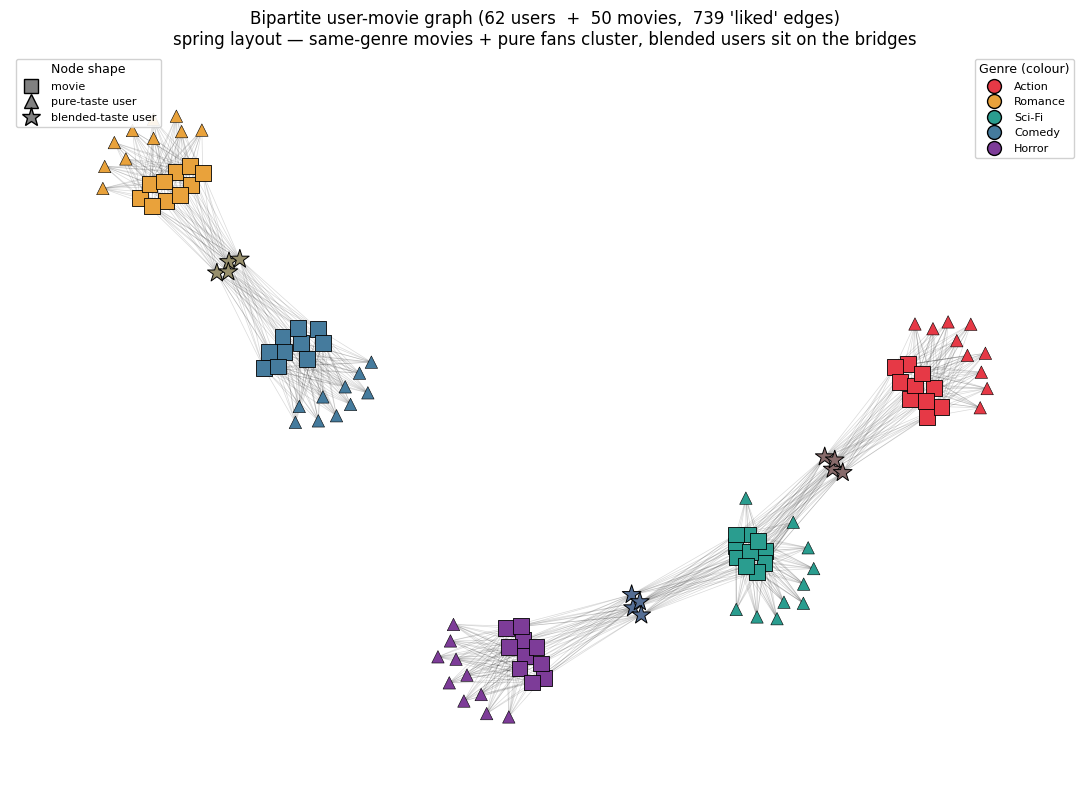

In [10]:
# ==============================================================================
# 1. IMPOSTAZIONE DEI PARAMETRI E SOGLIE
# ==============================================================================

# Definiamo il voto minimo per considerare che un utente abbia gradito ("liked") un film.
# Solo i voti maggiori o uguali a questa soglia genereranno un collegamento (arco) nel grafo.
THRESHOLD = 3.0

# Calcoliamo il numero totale di nodi combinando utenti (N_U) e film (N_M).
# Nel grafo, gli utenti occuperanno gli indici da 0 a N_U-1, 
# mentre i film occuperanno gli indici da N_U a N_U + N_M - 1.
N_TOTAL = N_U + N_M

# ==============================================================================
# 2. COSTRUZIONE DEL GRAFO BIPARTITO
# ==============================================================================

# Inizializziamo un oggetto Grafo vuoto, non orientato, usando la libreria NetworkX.
bipartite_G = nx.Graph()

# Aggiungiamo i nodi relativi agli utenti.
# range(N_U) genera numeri da 0 a N_U-1. Il flag bipartite='user' serve come metadato
# per identificare esplicitamente la natura di questo insieme di nodi.
bipartite_G.add_nodes_from(range(N_U), bipartite='user')

# Aggiungiamo i nodi relativi ai film.
# Gli ID dei film partono da N_U per evitare qualsiasi sovrapposizione numerica con gli ID degli utenti.
# Il flag bipartite='movie' identifica questo secondo insieme indipendente di nodi.
bipartite_G.add_nodes_from(range(N_U, N_U + N_M), bipartite='movie')

# Creiamo i collegamenti (archi o "edges") tra utenti e film tramite una List Comprehension.
# Cicliamo su ogni tripla (utente, film, voto) presente nel dataset 'ratings'.
# Se il voto 'r' è maggiore o uguale alla nostra soglia (THRESHOLD):
#   - Convertiamo l'ID utente in intero -> int(u)
#   - Trasliamo l'ID del film sommandogli N_U -> N_U + int(m) per farlo corrispondere al rispettivo nodo film.
bipartite_G.add_edges_from(
    (int(u), N_U + int(m)) for u, m, r in ratings if r >= THRESHOLD
)

# Stampiamo a schermo un riepilogo testuale della struttura del grafo bipartito appena generato.
print(f"Bipartite graph: {N_U} users + {N_M} movies = {bipartite_G.number_of_nodes()} nodes, "
      f"{bipartite_G.number_of_edges()} 'liked' edges")

# ==============================================================================
# 3. CALCOLO DEL LAYOUT SPAZIALE (SPRING LAYOUT)
# ==============================================================================

# Calcoliamo le coordinate (x, y) di ciascun nodo usando l'algoritmo Spring Layout (Fruchterman-Reingold).
# Questo algoritmo simula un sistema fisico in cui i collegamenti agiscono come molle che si contraggono,
# mentre i nodi non connessi si respingono come cariche elettriche dello stesso segno.
#   - seed=0: garantisce la riproducibilità del posizionamento ad ogni esecuzione.
#   - k=0.45: definisce la distanza ottimale di riposo tra i nodi (valori più alti allontanano i nodi).
#   - iterations=120: il numero di passaggi di simulazione fisica per stabilizzare il sistema.
# RISULTATO GEOMETRICO: I film dello stesso genere e i loro fan puri si attraggono in cluster densi,
# mentre gli utenti a gusto misto ("blended") vengono tirati da più cluster, posizionandosi nel mezzo ("ponti").
pos = nx.spring_layout(bipartite_G, seed=0, k=0.45, iterations=120)

# ==============================================================================
# 4. INIZIALIZZAZIONE DELLA FIGURA E DISEGNO DEGLI ARCHI
# ==============================================================================

# Creiamo una finestra di disegno (fig) e i suoi assi (ax) con una dimensione generosa (11x8 pollici).
fig, ax = plt.subplots(figsize=(11, 8))

# Disegniamo le linee di collegamento (gli archi) tra utenti e film.
#   - alpha=0.15: rende le linee molto trasparenti per evitare che l'alto numero di archi crei un groviglio illeggibile.
#   - width=0.5: imposta uno spessore della linea molto sottile e discreto.
nx.draw_networkx_edges(bipartite_G, pos, ax=ax, alpha=0.15, width=0.5)

# ==============================================================================
# 5. DISEGNO DEI NODI: I FILM
# ==============================================================================

# Generiamo la lista numerica dei nodi corrispondenti ai film (da N_U a N_U + N_M - 1).
movie_nodes = [N_U + m for m in range(N_M)]

# Associano a ogni singolo film il colore specifico del suo genere, estraendolo dal dizionario GENRE_COLORS.
movie_node_colors = [GENRE_COLORS[movie_genre[m]] for m in range(N_M)]

# Disegniamo i nodi dei film sugli assi:
#   - node_shape='s': i film vengono rappresentati come quadrati ("s" sta per square).
#   - node_size=130: dimensione del quadrato.
#   - edgecolors='black' e linewidths=0.6: aggiunge un leggero bordo nero intorno a ogni quadrato per staccarlo dallo sfondo.
nx.draw_networkx_nodes(bipartite_G, pos, ax=ax, nodelist=movie_nodes,
                       node_color=movie_node_colors, node_shape='s',
                       node_size=130, edgecolors='black', linewidths=0.6)

# ==============================================================================
# 6. DISEGNO DEI NODI: UTENTI A GUSTO PURO
# ==============================================================================

# Isoliama gli utenti a "gusto puro" filando l'array 'is_blend' (selezioniamo dove is_blend è False).
pure_users = [u for u in range(N_U) if not is_blend[u]]

# Disegniamo gli utenti puri sugli assi:
#   - node_shape='^': vengono rappresentati come triangoli.
#   - node_color=user_colors[pure_users]: assumono il colore mappato per il rispettivo utente.
#   - node_size=80: dimensione più contenuta rispetto ai film per non affollare lo spazio.
nx.draw_networkx_nodes(bipartite_G, pos, ax=ax, nodelist=pure_users,
                       node_color=user_colors[pure_users], node_shape='^',
                       node_size=80, edgecolors='black', linewidths=0.4)

# ==============================================================================
# 7. DISEGNO DEI NODI: UTENTI A GUSTO MISTO (BLENDED)
# ==============================================================================

# Isoliama gli utenti con gusti misti (selezioniamo dove is_blend è True).
blend_users = [u for u in range(N_U) if is_blend[u]]

# Disegniamo gli utenti misti sugli assi:
#   - node_shape='*': vengono rappresentati come stelle, per evidenziare la loro natura ibrida.
#   - node_size=200: dimensione volutamente grande per far risaltare visivamente questi nodi di "collegamento".
nx.draw_networkx_nodes(bipartite_G, pos, ax=ax, nodelist=blend_users,
                       node_color=user_colors[blend_users], node_shape='*',
                       node_size=200, edgecolors='black', linewidths=0.7)

# ==============================================================================
# 8. COSTRUZIONE MANUALE DELLE LEGENDE
# ==============================================================================

# Poiché abbiamo disegnato i nodi in gruppi separati, creiamo manualmente i simboli per le legende.
# Prima legenda: significato delle FORME geometriche (Quadrato=Film, Triangolo=Utente Puro, Stella=Utente Misto).
shape_handles = [
    Line2D([], [], marker='s', linestyle='', color='gray', markersize=10,
           markeredgecolor='black', label='movie'),
    Line2D([], [], marker='^', linestyle='', color='gray', markersize=10,
           markeredgecolor='black', label='pure-taste user'),
    Line2D([], [], marker='*', linestyle='', color='gray', markersize=14,
           markeredgecolor='black', label='blended-taste user'),
]

# Seconda legenda: significato dei COLORI (ogni colore corrisponde ad un genere cinematografico specifico).
genre_handles = [
    Line2D([], [], marker='o', linestyle='', color=GENRE_COLORS[g],
           markersize=10, markeredgecolor='black', label=GENRES[g])
    for g in range(len(GENRES))

]

# Rendering della prima legenda (Forme dei Nodi) posizionata in alto a sinistra.
legend_shapes = ax.legend(handles=shape_handles, loc='upper left',
                          title='Node shape', fontsize=8, title_fontsize=9, framealpha=0.9)

# Operazione fondamentale: aggiungiamo esplicitamente l'artista della prima legenda agli assi.
# Senza questa riga, la chiamata successiva a 'ax.legend' cancellerebbe la legenda precedente.
ax.add_artist(legend_shapes)

# Rendering della seconda legenda (Colori dei Generi) posizionata in alto a destra.
ax.legend(handles=genre_handles, loc='upper right',
          title='Genre (colour)', fontsize=8, title_fontsize=9, framealpha=0.9)

# ==============================================================================
# 9. RIFINITURA DEL GRAFICO E MOSTRA A SCHERMO
# ==============================================================================

# Impostiamo il titolo descrittivo principale in cima al grafico.
ax.set_title(f"Bipartite user-movie graph "
             f"({N_U} users  +  {N_M} movies,  {bipartite_G.number_of_edges()} 'liked' edges)\n"
             "spring layout — same-genre movies + pure fans cluster, blended users sit on the bridges")

# Spegniamo la visualizzazione degli assi X e Y (griglia e valori numerici).
# In questo tipo di visualizzazione spaziale conta solo la posizione relativa e la vicinanza dei nodi.
ax.set_axis_off()

# Ottimizziamo la disposizione degli elementi all'interno della figura per eliminare i margini bianchi in eccesso.
plt.tight_layout()

# Mostriamo finalmente il grafico renderizzato sullo schermo.
plt.show()

## 9. A GNN on the bipartite graph

Now we apply the same recipe as the session-10 GCN demo, but to *this* graph.

1. Build the normalised adjacency $\hat A = \tilde D^{-1/2}(A+I)\tilde D^{-1/2}$ over **all 112 nodes** (users and movies — to the GCN they're all just nodes).
2. Use identity features $X = I$ (no real features available).
3. Forward-pass through 2 GCN layers to get a hidden representation $H \in \mathbb{R}^{112 \times 16}$.
4. **Score a (user, movie) pair via the dot product of their GCN embeddings** — exactly like matrix factorisation, except now the embeddings are *computed by message passing* on the graph instead of looked up from a learnable table.
5. Train against the same MSE loss on observed ratings.

Architecturally, the only difference from §2 is that we replaced two `nn.Embedding` lookups with two GCN layers.

In [ ]:
import torch.nn.functional as F

# A_hat = D~^(-1/2) (A + I) D~^(-1/2)
A_full = nx.to_numpy_array(bipartite_G, nodelist=range(N_TOTAL)) + np.eye(N_TOTAL)
D = A_full.sum(axis=1)
A_hat = torch.tensor(np.diag(1.0 / np.sqrt(D)) @ A_full @ np.diag(1.0 / np.sqrt(D)),
                     dtype=torch.float32)
X_id = torch.eye(N_TOTAL, dtype=torch.float32)

class BipartiteGCN(nn.Module):
    def __init__(self, n, hidden):
        super().__init__()
        self.W1 = nn.Linear(n, hidden, bias=False)
        self.W2 = nn.Linear(hidden, hidden, bias=False)

    def forward(self, A_hat, X):
        H = F.relu(A_hat @ self.W1(X))
        return A_hat @ self.W2(H)             # 16-D node embeddings

torch.manual_seed(1)
gcn = BipartiteGCN(N_TOTAL, hidden=16)
opt_g = torch.optim.Adam(gcn.parameters(), lr=0.01, weight_decay=1e-4)

# rating triples → (user_node_idx, movie_node_idx) for the bipartite indexing
u_node = torch.tensor(ratings[:, 0], dtype=torch.long)
m_node = torch.tensor(N_U + ratings[:, 1], dtype=torch.long)

losses_gcn = []
for epoch in range(300):
    H = gcn(A_hat, X_id)
    pred = (H[u_node] * H[m_node]).sum(-1) + y_mean
    loss = ((pred - y) ** 2).mean()
    opt_g.zero_grad(); loss.backward(); opt_g.step()
    losses_gcn.append(loss.item())

print(f"GCN final MSE = {losses_gcn[-1]:.3f}   (rating range 1-5)")

## 10. Using the GCN as a recommender

So far we trained the GCN to minimise MSE on observed `(user, movie, rating)` triples — *exactly* the same training objective as matrix factorisation in §3. That means the GCN, like the MF, can predict a rating for **any** `(user, movie)` pair via

$$\hat r_{u, m} \;=\; H[u] \cdot H[N_U + m] \;+\; \bar y$$

and from those predicted ratings we can build a recommendation list by ranking movies for each user.

Below we pick three users — a pure Action fan, a pure Romance fan, and one of the blended `Romance+Comedy` users — and ask the GCN: *what would this user rate every movie?* The top-K of that list is the GCN's recommendation. We compare it against the matrix-factorisation prediction from §3 to see whether the two recommenders agree.

In [ ]:
# Compute predicted ratings for all (user, movie) pairs from each model.
def all_predictions_gcn():
    H = gcn(A_hat, X_id).detach()
    Hu, Hm = H[:N_U], H[N_U:]
    return (Hu @ Hm.T + y_mean).numpy()           # shape (N_U, N_M)

def all_predictions_mf():
    Umf = model.U.weight.detach()
    Mmf = model.M.weight.detach()
    return (Umf @ Mmf.T + y_mean).numpy()

P_gcn = all_predictions_gcn()
P_mf  = all_predictions_mf()

# Same true-rating matrix for reference
R_true = np.full((N_U, N_M), np.nan, dtype=np.float32)
for u, m, r in ratings:
    R_true[int(u), int(m)] = r

def describe_taste(u):
    label = blend_label_per_user[u]
    if label is not None:
        return f"blended ({label})"
    g, = user_taste[u]
    return f"pure {GENRES[g]}"

def top_k_recommend(name, u, k=5):
    print(f"\n=== {name}: user #{u}, taste = {describe_taste(u)} ===")
    print(f"{'movie':<24}{'genre':<10}{'true r':>8}{'MF r̂':>8}{'GCN r̂':>8}")
    print("-" * 58)
    # rank by GCN prediction (the headline recommender)
    order = np.argsort(-P_gcn[u])[:k]
    for m in order:
        print(f"{movie_title[m]:<24}{GENRES[movie_genre[m]]:<10}"
              f"{R_true[u, m]:>8.2f}{P_mf[u, m]:>8.2f}{P_gcn[u, m]:>8.2f}")

top_k_recommend("Pure Action fan", u=0)
top_k_recommend("Pure Romance fan", u=10)
top_k_recommend("Blended Romance+Comedy fan", u=54)

# Quick aggregate sanity check: for each user, average predicted rating
# on their preferred-genre movies vs. all other movies.
def avg_pred_by_taste(P):
    matches, others = [], []
    for u in range(N_U):
        for m in range(N_M):
            if movie_genre[m] in user_taste[u]:
                matches.append(P[u, m])
            else:
                others.append(P[u, m])
    return np.mean(matches), np.mean(others)

mf_match, mf_other = avg_pred_by_taste(P_mf)
gcn_match, gcn_other = avg_pred_by_taste(P_gcn)

print("\n--- Average predicted rating ---")
print(f"           matched-genre  other-genre   gap")
print(f"MF       :     {mf_match:.2f}          {mf_other:.2f}      {mf_match - mf_other:.2f}")
print(f"GCN      :     {gcn_match:.2f}          {gcn_other:.2f}      {gcn_match - gcn_other:.2f}")
print("(true)   :      4.50          1.50      3.00")

## 11. Comparing the two embedding methods

Let's plot the two embeddings side by side and see whether the GCN reproduces the pentagon-shaped genre geometry that matrix factorisation found in §4.

The matrix-factorisation embeddings live in $\mathbb{R}^2$ directly. The GCN embeddings live in $\mathbb{R}^{16}$, so we project them to 2D with PCA. PCA picks the directions of greatest variance — the orientation will differ from MF, but the cluster structure should be the same.

In [ ]:
# PCA the GCN embeddings down to 2D
H_final = gcn(A_hat, X_id).detach().numpy()
Hc = H_final - H_final.mean(0, keepdims=True)
_, _, Vt = np.linalg.svd(Hc, full_matrices=False)
Z = Hc @ Vt[:2].T
Zu, Zm = Z[:N_U], Z[N_U:]

# Matrix-factorisation embeddings, taken straight from the model trained in §3
U_mf = model.U.weight.detach().numpy()
M_mf = model.M.weight.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

def plot_embeddings(ax, M, U, title):
    for g in range(len(GENRES)):
        mask = movie_genre == g
        ax.scatter(M[mask, 0], M[mask, 1],
                   c=GENRE_COLORS[g], s=130, marker='s',
                   edgecolor='black', linewidth=0.5, alpha=0.85,
                   label=f'{GENRES[g]} movie')
    pure = ~is_blend
    ax.scatter(U[pure, 0], U[pure, 1],
               c=user_colors[pure], s=85, marker='^',
               edgecolor='black', linewidth=0.4, alpha=0.85,
               label='pure-taste user')
    ax.scatter(U[is_blend, 0], U[is_blend, 1],
               c=user_colors[is_blend], s=180, marker='*',
               edgecolor='black', linewidth=0.7,
               label='blended-taste user')
    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.3)
    ax.axhline(0, c='gray', lw=0.5); ax.axvline(0, c='gray', lw=0.5)
    ax.set_aspect('equal')

plot_embeddings(axes[0], M_mf, U_mf,
                f"Matrix factorisation (§4)\nlookup table + dot product, MSE = {losses[-1]:.2f}")
plot_embeddings(axes[1], Zm, Zu,
                f"Bipartite GCN (§8)\nmessage passing + dot product, MSE = {losses_gcn[-1]:.2f}")
axes[0].legend(fontsize=7, loc='best', framealpha=0.85)

fig.suptitle("Same data, two ways to compute embeddings — same emergent geometry", fontsize=13)
plt.tight_layout()
plt.show()

## 12. So what changed by switching to a GNN?

The two pictures tell the same story — same genre clusters, blended users sitting between, pentagon-like layout. The ingredients are identical:

- same data: `(user, movie, rating)` triples,
- same scoring rule: $\mathbf{u} \cdot \mathbf{m} + \bar y$,
- same MSE loss on observed ratings.

The **only** difference is how the embedding for a node is *produced*:

| | Matrix factorisation (§4) | GCN on bipartite graph (§8) |
|---|---|---|
| Embedding for $u$ | row of a learnable lookup table | $\hat A^2 X W_1 W_2$ (post-ReLU) — a function of $u$'s graph neighbourhood |
| New user with no ratings | no embedding (cold start) | embedding computed from neighbours' embeddings — **inductive** |
| Uses node features | no | yes (we used identity here, but real systems plug in user/item features) |
| Captures multi-hop structure | only via dot-product geometry | explicitly: 2 GCN layers = 2-hop neighbourhood |
| Within-category variation | each item has its own learnable row → spread out | same-genre items have nearly identical neighbourhoods → embeddings **collapse together** |

That last row is worth dwelling on — it's the headline trade-off.

### Oversmoothing: a real GCN failure mode

Look closely at the GCN panel: same-genre movie squares stack right on top of each other, and their pure-taste fans land essentially at the same point. The MF panel doesn't have this — each Action movie has its own slightly different position.

Why? Two Action movies have **almost identical 1-hop neighbourhoods** (the same Action fans rate them both), and almost identical 2-hop neighbourhoods (the same other movies those fans also like). After two GCN layers, message passing has averaged each pair of Action movies into nearly the same vector. We've collapsed the within-genre variation that the lookup-table model preserved.

This is **oversmoothing**, and it's a well-known property of GCN-style aggregation. Stack more layers and it gets worse — every node converges to the same vector. Practical GNN-based recommenders (LightGCN, NGCF, …) sidestep this by *combining* a learnable per-node embedding with a small number of GCN layers — keeping the per-item identity from MF and the graph-aware aggregation from GCN.

### What the graph view buys us

Despite the oversmoothing, framing the recommender as a graph is a genuine upgrade in a few ways:

- **Inductive on new users / movies.** Add a new user with three ratings → wire their three edges into the graph and re-run the forward pass. No retraining. Matrix factorisation can't do this without retraining.
- **Drops in heterogeneous information for free.** Add a `tag` node type, edge it to relevant movies, and the GCN starts using tag co-occurrence in its aggregation.
- **Same architecture as session 08 / session 10.** Once we see this trick, recommenders, citation networks, and social graphs are all the same problem with different node and edge sets.

This is the bridge into the graph half of the course.